<a href="https://colab.research.google.com/github/pinTung/manufaccturing-detection/blob/main/0305_claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Detection of Manufacturing Defects in Steel Using Deep Learning With Explainable Artificial Intelligence

##### U-Net & FPN架構進行鋼鐵缺陷檢測
<p>建立結合 XAI 的深度學習缺陷檢測系統


1.   Dataset：Severstal 鋼鐵缺陷資料集
2.   Data Augmentation：幾何轉換（旋轉、平移、縮放、翻轉）、雜訊注入（Gaussian noise、Salt & Pepper noise）
3. Models：U-Net、FPN、Backbone: ResNet34, InceptionV3, EfficientNetB4
4. XAI：GradCAM、SHAP、LIME </p>
<p>實驗</p>

*   TensorFlow/Keras，GPU 訓練，資料分為 60/20/20（train/val/test）


In [ ]:
#cell_1
import os, math, random, gc
import numpy as np
import pandas as pd
import cv2

import tensorflow as tf
from tensorflow import keras
from keras import layers as L

from glob import glob
import albumentations as A

print("TF:", tf.__version__)
print("Keras:", keras.__version__)
print("albumentations:", A.__version__)

TF: 2.19.0
Keras: 3.10.0
albumentations: 2.0.8


In [ ]:
#cell_2
# ==== 1) Paths & constants ====
DATA_DIR = "/content/data"       # change if needed
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_DIR = os.path.join(DATA_DIR, "train_images")
TEST_DIR  = os.path.join(DATA_DIR, "test_images")   # no labels, only for demo

IMG_H, IMG_W = 128, 800         # paper setting
N_CLASSES = 4                    # defect classes (1..4)

EPOCHS = 30
BATCH  = 8
LR     = 1e-5

# Options
BACKBONE = "efficientnetb4"      # 'resnet34' | 'inceptionv3' | 'efficientnetb4'
ARCH     = "fpn"                # 'unet' | 'fpn'
NOISE_SETTING = "low"            # 'none' | 'low' | 'high'
RANDOM_SEED   = 42

os.makedirs(DATA_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
#cell_3
## 1、下載kaggle 利用上傳kaggle金鑰的方式把資料集下載進來
from google.colab import files
files.upload()  # upload kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!mkdir -p "$DATA_DIR"
!kaggle competitions download -c severstal-steel-defect-detection -p "$DATA_DIR"
# unzip all
import glob, zipfile
for z in glob.glob(os.path.join(DATA_DIR, "*.zip")):
    with zipfile.ZipFile(z) as zz:
        zz.extractall(DATA_DIR)
print("Data files:", os.listdir(DATA_DIR))

Saving kaggle.json to kaggle.json
 99% 1.55G/1.57G [00:01<00:00, 1.66GB/s]
100% 1.57G/1.57G [00:01<00:00, 1.65GB/s]
Data files: ['sample_submission.csv', 'test_images', 'severstal-steel-defect-detection.zip', 'train.csv', 'train_images']


## 資料標準化
####def read_train_csv(path)：將資料欄位合併，讀進csv
####rle_decode(mask_rle, shape)：把 Kaggle 的 RLE 字串解成二元遮罩
####rle_encode(img)：把二元遮罩編回 Kaggle 的 RLE 格式
####split_id(cls)：把 "ImageId_ClassId" 拆成 (img_id, class_id:int)

In [ ]:
# 標準化：統一 Kaggle train.csv 的兩欄/三欄版本
# 最後輸出保留 ImageId_ClassId 和 EncodedPixels（並可正確統計「有缺陷影像數」）

import os
import glob
import numpy as np
import pandas as pd

def read_train_csv(path: str) -> pd.DataFrame:
    """Read Severstal train.csv in either 2-col or 3-col format and normalize to:
       columns = [ImageId_ClassId, EncodedPixels]
    """
    if not os.path.exists(path):
        print(f"[WARN] train.csv not found: {path}")
        # allow dry run
        return pd.DataFrame(columns=["ImageId_ClassId", "EncodedPixels"])

    raw = pd.read_csv(path)
    cols = set(map(str, raw.columns))

    if {"ImageId_ClassId", "EncodedPixels"}.issubset(cols):
        df = raw[["ImageId_ClassId", "EncodedPixels"]].copy()

    elif {"ImageId", "ClassId", "EncodedPixels"}.issubset(cols):
        df = raw[["ImageId", "ClassId", "EncodedPixels"]].copy()
        df["ImageId_ClassId"] = df["ImageId"].astype(str) + "_" + df["ClassId"].astype(str)
        df = df[["ImageId_ClassId", "EncodedPixels"]]

    else:
        raise ValueError(f"Unexpected CSV format. Columns = {list(raw.columns)}")

    return df


df = read_train_csv(TRAIN_CSV)

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images")
all_image_ids = sorted(os.path.basename(p) for p in glob.glob(os.path.join(TRAIN_IMG_DIR, "*.jpg")))
total_images = len(all_image_ids)

# ✅ 正確統計「有缺陷影像」：必須先過濾 EncodedPixels 非空/非 NaN
has_mask = df["EncodedPixels"].notna() & (df["EncodedPixels"].astype(str).str.strip() != "")
defect_img_ids = (
    df.loc[has_mask, "ImageId_ClassId"]
      .astype(str)
      .str.rsplit("_", n=1).str[0]
      .unique()
)
defect_count = len(defect_img_ids)
no_defect_count = total_images - defect_count

print("總影像數：", total_images)
print("有缺陷：", defect_count)
print("無缺陷：", no_defect_count)


# 把 RLE 字串還原成 (H, W) 的 0/1 遮罩
# ⚠️ Severstal 常用 Fortran order；shape 必須用 (256, 1600) = (H, W)
def rle_decode(mask_rle, shape):
    if not isinstance(mask_rle, str) or mask_rle.strip() == "":
        return np.zeros(shape, dtype=np.uint8)

    s = mask_rle.strip().split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    return img.reshape((shape[0], shape[1]), order="F")


# 把 2D 遮罩轉回 Kaggle 規格的 RLE 字串
def rle_encode(img):
    pixels = img.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)


# 把 ImageId_ClassId 拆回 (img_id, class_id:int)（用 rsplit 比較安全）
def split_id(s: str):
    img_id, cls_id = s.rsplit("_", 1)
    return img_id, int(cls_id)


總影像數： 12568
有缺陷： 6666
無缺陷： 5902


##資料前處理
##資料擴增（訓練資料）

In [ ]:
from glob import glob

if "ImageId" not in df.columns:
    df["ImageId"] = df["ImageId_ClassId"].astype(str).str.rsplit("_", n=1).str[0]
groups = df.groupby("ImageId")

# all images from folder (includes pos/neg like the paper setup)
all_ids = sorted(os.path.basename(p) for p in glob(os.path.join(TRAIN_DIR, "*.jpg")))

rng = np.random.RandomState(RANDOM_SEED)
idx = rng.permutation(len(all_ids))
n = len(all_ids)
a = int(0.6 * n)
b = int(0.8 * n)

tr_ids_raw = [all_ids[i] for i in idx[:a]]   # 🔹 原始訓練集
va_ids     = [all_ids[i] for i in idx[a:b]]
te_ids     = [all_ids[i] for i in idx[b:]]



# # --- Oversampling (image-level) ---
upsample_ratio = {1: 6, 2: 12, 3: 3, 4: 6}

tr_ids = []
for img_id in tr_ids_raw:
    repeat_count = 1

    if img_id in groups.groups:
        g = groups.get_group(img_id)

        present_classes = set()
        for _, row in g.iterrows():
            rle = row.get("EncodedPixels", "")
            if isinstance(rle, str) and rle.strip():
                cls_id = int(str(row["ImageId_ClassId"]).rsplit("_", 1)[1])
                present_classes.add(cls_id)

        if present_classes:
            repeat_count = max(upsample_ratio.get(c, 1) for c in present_classes)

    tr_ids.extend([img_id] * repeat_count)

rng.shuffle(tr_ids)

print(f"Train raw = {len(tr_ids_raw)}  -> oversampled = {len(tr_ids)}")

Train raw = 7540  -> oversampled = 19743


In [ ]:
# ------------------------------------------------------------
# 1) image + 4-channel mask loader (OK, just minor cleanup)
# ------------------------------------------------------------
def load_image_and_mask(img_id, df_group):
    path = os.path.join(TRAIN_DIR, img_id)
    img0 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img0 is None:
        img0 = np.zeros((256, 1600), np.uint8)

    H0, W0 = img0.shape[:2]
    mask4 = np.zeros((H0, W0, N_CLASSES), np.uint8)

    # ✅ 關鍵修正：df_group 可能是 None
    if df_group is not None:
        for _, row in df_group.iterrows():
            cls_id = int(str(row["ImageId_ClassId"]).rsplit("_", 1)[1])
            ch = cls_id - 1
            rle = row.get("EncodedPixels", "")
            if isinstance(rle, str) and rle.strip():
                mask4[..., ch] = rle_decode(rle, shape=(H0, W0))

    img = cv2.resize(img0, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    mask = np.stack(
        [
            cv2.resize(mask4[..., k], (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
            for k in range(N_CLASSES)
        ],
        axis=-1,
    )
    return img, mask

# ------------------------------------------------------------
# 2) preprocessing (FIXED): 根據 backbone 選擇對應的 preprocess_input
# ------------------------------------------------------------
def preprocess_image(img_u8, backbone=BACKBONE):
    # ensure (H,W,C)
    if img_u8.ndim == 2:
        img_u8 = img_u8[..., None]

    # ensure 3 channels for ImageNet backbones (EfficientNet/Inception/ResNet)
    C = img_u8.shape[-1]
    if C == 1:
        img_u8 = np.repeat(img_u8, 3, axis=-1)
    elif C > 3:
        img_u8 = img_u8[..., :3]  # safe fallback

    img = img_u8.astype("float32")  # keep range 0..255

    if backbone == "resnet50":
        return tf.keras.applications.resnet50.preprocess_input(img)
    elif backbone == "inceptionv3":
        return tf.keras.applications.inception_v3.preprocess_input(img)
    else:  # efficientnetb4
        return tf.keras.applications.efficientnet.preprocess_input(img)


# ------------------------------------------------------------
# 3) augmentation application (keep logic, just clean)
# ------------------------------------------------------------
def apply_aug(img_u8, mask_u8, aug):
    if aug is None:
        return preprocess_image(img_u8), mask_u8.astype("float32")

    x = img_u8 if img_u8.ndim == 3 else img_u8[..., None]
    out = aug(image=x, mask=mask_u8)

    img_u8_aug = out["image"]
    msk = out["mask"].astype("float32")

    img = preprocess_image(img_u8_aug)
    return img, msk


##加噪聲
##**papper & salt **：用來模擬「感測器／傳輸／表面缺陷造成的極端像素錯誤」，測的是模型對「局部、突發、非連續退化」的穩健性

##**Gaussian blur**：高斯模糊是用來模擬「影像解析度與清晰度下降」的噪聲，它測試的是模型在「邊界與細節被抹掉」時，是否仍能正確做分割。

In [ ]:
import albumentations as A
import numpy as np
import cv2

# ── 噪聲函數（Lambda 版本，不受 albumentations 版本影響）──

def make_gauss_noise(std):
    def _apply(image, **kwargs):
        img = image.astype(np.float32)
        noise = np.random.normal(0, std, img.shape)
        img = img + noise
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img
    return A.Lambda(image=_apply, p=1.0)

def make_salt_pepper(pepper_thr, salt_thr):
    def _apply(image, **kwargs):
        img = image.copy()
        rnd = np.random.rand(*img.shape[:2])
        img[rnd < pepper_thr] = 0
        img[rnd > salt_thr] = 255
        return img
    return A.Lambda(image=_apply, p=1.0)


# ── 訓練增強（混合三種噪聲等級，符合教授要求的單一模型）──

def build_train_aug(noise_setting="none", paper_strict=True):
    ops = [
        # 幾何變換（改用 Affine 取代已棄用的 ShiftScaleRotate）
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.0 if paper_strict else 0.2),
        A.Affine(
            translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
            scale=(0.95, 1.05),
            rotate=(-10, 10),
            mode=cv2.BORDER_REFLECT,
            p=0.8,
        ),
    ]

    if noise_setting == "low":
        ops.append(A.Compose([
            A.GaussianBlur(blur_limit=(3, 3), p=1.0),   # 修正：最小值需 >= 3
            make_gauss_noise(std=20),
            make_salt_pepper(pepper_thr=0.05, salt_thr=0.95),
        ], p=0.5))

    elif noise_setting == "high":
        ops.append(A.Compose([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            make_gauss_noise(std=50),
            make_salt_pepper(pepper_thr=0.10, salt_thr=0.90),
        ], p=0.5))

    # noise_setting="none" 不加任何噪聲

    return A.Compose(ops)


# ── 測試增強 ──

def build_test_noise_aug(noise_setting="none"):
    if noise_setting in ["none", "clean", None]:
        return A.Compose([])

    if noise_setting == "low":
        return A.Compose([
            A.GaussianBlur(blur_limit=(3, 3), p=1.0),   # 修正：最小值需 >= 3
            make_gauss_noise(std=20),
            make_salt_pepper(pepper_thr=0.05, salt_thr=0.95),
        ])

    if noise_setting == "high":
        return A.Compose([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            make_gauss_noise(std=50),
            make_salt_pepper(pepper_thr=0.10, salt_thr=0.90),
        ])

    raise ValueError(f"Unknown noise_setting: {noise_setting}")


In [ ]:
# ------------------------------------------------------------
# 6) generator (OK)
# ------------------------------------------------------------
def gen(ids, aug):
    for img_id in ids:
        if img_id in groups.groups:
            g = groups.get_group(img_id)
            img_u8, mask_u8 = load_image_and_mask(img_id, g)
        else:
            p = os.path.join(TRAIN_DIR, img_id)
            im0 = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if im0 is None:
                im0 = np.zeros((256, 1600), np.uint8)
            img_u8 = cv2.resize(im0, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
            mask_u8 = np.zeros((IMG_H, IMG_W, N_CLASSES), np.uint8)

        img, msk = apply_aug(img_u8, mask_u8, aug)
        yield img, msk

# ------------------------------------------------------------
# 7) make_ds (FIXED): shuffle -> repeat -> batch
# ------------------------------------------------------------
def make_ds(ids, aug, batch=BATCH, shuffle=False, repeat=False):
    out_sig = (
        tf.TensorSpec((IMG_H, IMG_W, 3), tf.float32),
        tf.TensorSpec((IMG_H, IMG_W, N_CLASSES), tf.float32),
    )
    ds = tf.data.Dataset.from_generator(lambda: gen(ids, aug), output_signature=out_sig)

    if shuffle:
        ds = ds.shuffle(1024, seed=RANDOM_SEED, reshuffle_each_iteration=True)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

print("raw train:", len(tr_ids_raw))
print("oversampled train:", len(tr_ids))
print("val:", len(va_ids), "test:", len(te_ids))

raw train: 7540
oversampled train: 19743
val: 2514 test: 2514


In [ ]:
print("NOISE_SETTING :",NOISE_SETTING)
train_aug = build_train_aug(noise_setting=NOISE_SETTING, paper_strict=True)
val_aug   = A.Compose([])
test_aug  = build_test_noise_aug(noise_setting=NOISE_SETTING)

train_ds = make_ds(tr_ids, aug=train_aug, shuffle=True,  repeat=True)
val_ds   = make_ds(va_ids, aug=val_aug,   shuffle=False, repeat=False)
test_ds  = make_ds(te_ids, aug=test_aug,  shuffle=False, repeat=False)


NOISE_SETTING : low


/tmp/ipykernel_1052/3764633815.py:33: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(


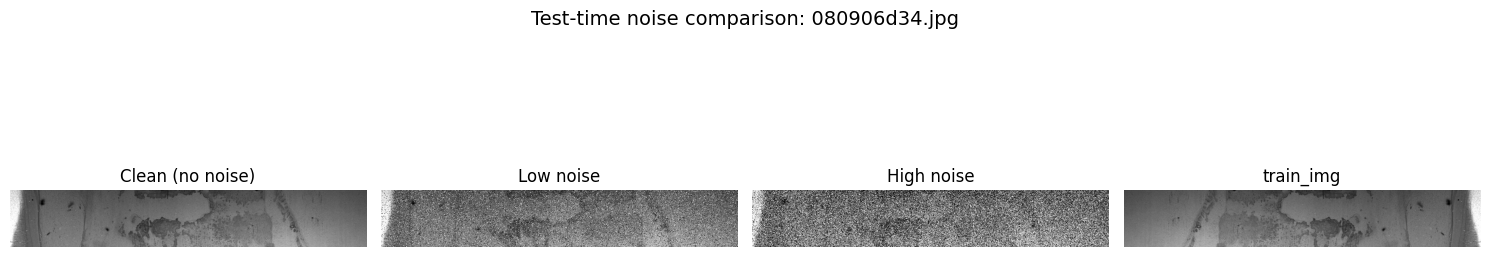

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_test_noise_example(img_id):
    # 1) load raw image (uint8, grayscale)
    df_group = groups.get_group(img_id) if img_id in groups.groups else None
    img_u8, mask_u8 = load_image_and_mask(img_id, df_group)

    # 為了顯示用 normalize（只影響顯示）
    def norm01(x):
        x = x.astype(np.float32)
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

    # 2) build three test-time augs
    aug_clean = build_test_noise_aug("none")
    aug_low   = build_test_noise_aug("low")
    aug_high  = build_test_noise_aug("high")

    # 3) apply (注意：apply_aug 會 preprocess，但我們只看 raw aug 前)
    x_clean = aug_clean(image=img_u8[..., None])["image"]
    x_low   = aug_low(image=img_u8[..., None])["image"]
    x_high  = aug_high(image=img_u8[..., None])["image"]
    train_img = train_aug(image=img_u8[..., None])["image"]

    # 4) plot
    plt.figure(figsize=(15, 4))

    for i, (title, x) in enumerate([
        ("Clean (no noise)", x_clean),
        ("Low noise", x_low),
        ("High noise", x_high),
        ("train_img", train_img),
    ]):
        plt.subplot(1, 4, i + 1)
        plt.imshow(norm01(x[..., 0]), cmap="gray")
        plt.title(title)
        plt.axis("off")

    plt.suptitle(f"Test-time noise comparison: {img_id}", fontsize=14)
    plt.tight_layout()
    plt.show()


# === 隨便挑一張 test image 來看 ===
visualize_test_noise_example(te_ids[0])


原始像素 std : 50.89
加噪後像素 std: 64.97


/tmp/ipykernel_1052/955239785.py:17: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.savefig('noise_check.png')
/tmp/ipykernel_1052/955239785.py:17: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.savefig('noise_check.png')
/tmp/ipykernel_1052/955239785.py:17: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.savefig('noise_check.png')
/tmp/ipykernel_1052/955239785.py:17: UserWarning: Glyph 22122 (\N{CJK UNIFIED IDEOGRAPH-566A}) missing from font(s) DejaVu Sans.
  plt.savefig('noise_check.png')
/tmp/ipykernel_1052/955239785.py:17: UserWarning: Glyph 32882 (\N{CJK UNIFIED IDEOGRAPH-8072}) missing from font(s) DejaVu Sans.
  plt.savefig('noise_check.png')
/tmp/ipykernel_1052/955239785.py:17: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.savefig('noise_check.png')
/usr/local/lib/python3.12/di

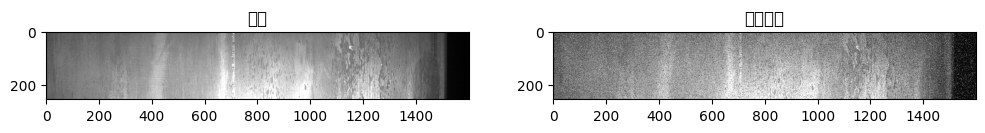

In [ ]:
img = cv2.imread(os.path.join(TRAIN_DIR,tr_ids_raw[2]),cv2.IMREAD_GRAYSCALE)

aug_low = A.Compose([
    A.GaussianBlur(blur_limit=(1, 1), p=1.0),
    make_gauss_noise(std=20),
    make_salt_pepper(pepper_thr=0.05, salt_thr=0.95),
])

noisy = aug_low(image=img)['image']

print(f"原始像素 std : {img.std():.2f}")
print(f"加噪後像素 std: {noisy.std():.2f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('原始')
plt.subplot(1,2,2); plt.imshow(noisy, cmap='gray'); plt.title('低噪聲後')
plt.savefig('noise_check.png')

##損失函數
##macro_double_soft_dice_loss：同樣是 macro Dice

##per_class_focal_loss：每個 class 用不同 alpha（tuple） 的 focal BCE

##combined_loss_pc = per-class focal + macro dice

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

## 0104改成不同的alpha權重，讓模型著重類別二
@register_keras_serializable(package="custom", name="macro_double_soft_dice_loss")
def macro_double_soft_dice_loss(y_true, y_pred, eps=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    inter = tf.reduce_sum(y_true * y_pred, axis=[1, 2])      # (B,C)
    denom = tf.reduce_sum(y_true + y_pred, axis=[1, 2])      # (B,C)
    dice  = (2.0 * inter + eps) / (denom + eps)              # (B,C)

    return 1.0 - tf.reduce_mean(dice)                        # macro over B and C


@register_keras_serializable(package="custom", name="per_class_focal_loss")
def per_class_focal_loss(y_true, y_pred, alpha=(0.6, 0.85, 0.25, 0.35), gamma=2.0, eps=1e-7):
    """
    alpha: (a1,a2,a3,a4) 對應 Defect1~4
    直覺：Defect2 最稀有 → 給最大 alpha
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), eps, 1.0 - eps)

    alpha = tf.constant(alpha, dtype=tf.float32)          # (C,)
    alpha = tf.reshape(alpha, (1, 1, 1, -1))              # broadcast -> (1,1,1,C)

    ce = - (y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))

    pt = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)

    # per-class alpha weighting
    weight = alpha * y_true + (1.0 - alpha) * (1.0 - y_true)

    fl = weight * tf.pow(1.0 - pt, gamma) * ce

    return tf.reduce_mean(fl)


# 修正：registered name 改為 "combined_loss" 與 custom_objects key 一致
@register_keras_serializable(package="custom", name="combined_loss")
def combined_loss(y_true, y_pred):
    return per_class_focal_loss(y_true, y_pred) + macro_double_soft_dice_loss(y_true, y_pred)


In [ ]:
@register_keras_serializable(package="custom", name="macro_dice_score")
def macro_dice_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # 1. 計算每個類別的 Intersection (只在 H, W 加總)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1, 2])

    # 2. 計算每個樣本每個類別的 Dice Score
    dice_score = (2.0 * intersection + 1e-7) / (denominator + 1e-7)

    # 3. 先對 Batch 取平均，再對 4 個類別取平均 (Macro Average)
    return tf.reduce_mean(dice_score)

@register_keras_serializable(package="custom", name="macro_iou_score")
def macro_iou_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2]) - intersection

    iou_score = (intersection + 1e-7) / (union + 1e-7)

    return tf.reduce_mean(iou_score)

In [ ]:
# ==== 6) Backbones & models (REVISED for correctness + paper-aligned behavior) ====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

print("模型架構設定 :",ARCH,BACKBONE)
# ------------------------------------------------------------
# Backbone getter
# - Fix: "resnet34" was incorrectly using ResNet50.
#   Keras doesn't ship ResNet34; use "resnet50" (honest naming) for now.
# - Keep your InceptionV3 / EfficientNetB4 feature taps.
# - Add: optional debug prints for feature shapes.
# ------------------------------------------------------------
def get_backbone(x, name, debug=False):
    if name == "resnet50":
        bb = tf.keras.applications.ResNet50(
            include_top=False, weights="imagenet", input_tensor=x
        )
        # 1/4, 1/8, 1/16, 1/32
        feats = [bb.get_layer(n).output for n in
                 ["conv2_block3_out", "conv3_block4_out", "conv4_block6_out", "conv5_block3_out"]]

    elif name == "inceptionv3":
        bb = tf.keras.applications.InceptionV3(
            include_top=False, weights="imagenet", input_tensor=x
        )
        # approx 1/4, 1/8, 1/16, 1/32
        feats = [bb.get_layer(n).output for n in ["mixed2", "mixed5", "mixed8", "mixed10"]]

    elif name == "efficientnetb4":
        bb = tf.keras.applications.EfficientNetB4(
            include_top=False, weights="imagenet", input_tensor=x
        )
        # intended ~1/4, 1/8, 1/16, 1/32 (verify by debug=True)
        feats = [bb.get_layer(n).output for n in ["block2b_add", "block3b_add", "block5c_add", "block7b_add"]]

    else:
        raise ValueError(f"Unknown BACKBONE: {name}")

    if debug:
        for i, f in enumerate(feats, start=2):
            print(f"c{i} shape:", f.shape)

    return bb, feats


# ------------------------------------------------------------
# Basic blocks
# ------------------------------------------------------------
def conv_block(x, filters, k=3):
    x = L.Conv2D(filters, k, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)
    return x

def up_block(x, skip, filters):
    x = L.UpSampling2D((2, 2), interpolation="bilinear")(x)
    if skip is not None:
        x = L.Concatenate()([x, skip])
    x = conv_block(x, filters)
    x = conv_block(x, filters)
    return x


# ------------------------------------------------------------
# U-Net (REVISED)
# Fix: Remove hard-coded x4 upsample. Always resize logits to (IMG_H, IMG_W).
# This prevents silent shape bugs across backbones.
# ------------------------------------------------------------
def build_unet(backbone_name="efficientnetb4", debug=False):
    inp = L.Input((IMG_H, IMG_W, 3))
    bb, (c2, c3, c4, c5) = get_backbone(inp, backbone_name, debug=debug)  # intended 1/4..1/32

    x = conv_block(c5, 512)
    x = up_block(x, c4, 256)  # -> ~1/16
    x = up_block(x, c3, 128)  # -> ~1/8
    x = up_block(x, c2,  64)  # -> ~1/4

    # logits -> resize to exact output size -> sigmoid
    logits = L.Conv2D(N_CLASSES, 1, activation=None, name="logits")(x)
    logits = L.Resizing(IMG_H, IMG_W, interpolation="bilinear", name="resize_to_output")(logits)
    out = L.Activation("sigmoid", name="sigmoid")(logits)

    model = keras.Model(inp, out, name=f"unet_{backbone_name}")
    return model


# ------------------------------------------------------------
# FPN (REVISED)
# - Make upsampling interpolation explicit (nearest) to align with typical FPN description.
# - Keep your "fuse to 1/4 then decode" head, but make final output size exact via Resizing.
# ------------------------------------------------------------
def build_fpn(backbone_name="efficientnetb4", out_channels=128, debug=False):
    inp = L.Input((IMG_H, IMG_W, 3))
    bb, (c1, c2, c3, c4) = get_backbone(inp, backbone_name, debug=debug)  # intended 1/4..1/32

    up2 = lambda t: L.UpSampling2D((2, 2), interpolation="nearest")(t)

    # lateral 1x1
    p4 = L.Conv2D(out_channels, 1, name="lat_p4")(c4)  # ~1/32
    p3 = L.Add(name="p3_add")([up2(p4), L.Conv2D(out_channels, 1, name="lat_c3")(c3)])  # ~1/16
    p2 = L.Add(name="p2_add")([up2(p3), L.Conv2D(out_channels, 1, name="lat_c2")(c2)])  # ~1/8
    p1 = L.Add(name="p1_add")([up2(p2), L.Conv2D(out_channels, 1, name="lat_c1")(c1)])  # ~1/4

    # smooth
    p4 = conv_block(p4, out_channels)
    p3 = conv_block(p3, out_channels)
    p2 = conv_block(p2, out_channels)
    p1 = conv_block(p1, out_channels)

    # fuse to ~1/4 scale (explicit nearest upsampling)
    p4_14 = L.UpSampling2D((8, 8), interpolation="nearest")(p4)  # 1/32 -> 1/4
    p3_14 = L.UpSampling2D((4, 4), interpolation="nearest")(p3)  # 1/16 -> 1/4
    p2_14 = L.UpSampling2D((2, 2), interpolation="nearest")(p2)  # 1/8  -> 1/4

    x = L.Concatenate(name="fpn_concat")([p4_14, p3_14, p2_14, p1])
    x = conv_block(x, 128)
    x = conv_block(x, 64)

    logits = L.Conv2D(N_CLASSES, 1, activation=None, name="logits")(x)
    logits = L.Resizing(IMG_H, IMG_W, interpolation="bilinear", name="resize_to_output")(logits)
    out = L.Activation("sigmoid", name="sigmoid")(logits)

    model = keras.Model(inp, out, name=f"fpn_{backbone_name}")
    return model


# ------------------------------------------------------------
# Build + compile
# ------------------------------------------------------------
def build_model(arch=ARCH, backbone=BACKBONE, debug_backbone=False):
    if arch == "unet":
        model = build_unet(backbone, debug=debug_backbone)
    elif arch == "fpn":
      print('fpn')
      model = build_fpn(backbone, debug=debug_backbone)
    else:
        raise ValueError(f"Unknown ARCH: {arch}")

    opt = keras.optimizers.Adam(LR)

    model.compile(
        optimizer=opt,
        loss=combined_loss,
        metrics=[macro_dice_score, macro_iou_score],
    )
    return model


# Example usage:
model = build_model(arch=ARCH, backbone=BACKBONE, debug_backbone=True)
model.summary(line_length=120)

print("BATCH =", BATCH)
print("train images =", len(tr_ids))
print("val images   =", len(va_ids))

steps_per_epoch  = max(1, int(np.ceil(len(tr_ids) / BATCH)))
validation_steps = max(1, int(np.ceil(len(va_ids) / BATCH)))

print("steps_per_epoch   =", steps_per_epoch)
print("validation_steps  =", validation_steps)
print("~train samples/epoch =", steps_per_epoch * BATCH)


模型架構設定 : fpn efficientnetb4
fpn
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
c2 shape: (None, 32, 200, 32)
c3 shape: (None, 16, 100, 56)
c4 shape: (None, 8, 50, 160)
c5 shape: (None, 4, 25, 448)


Model: "fpn_efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ input_layer (InputLayer)          │ (None, 128, 800, 3)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ rescaling (Rescaling)             │ (None, 128, 800, 3)          │                 0 │ input_layer[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ normalization (Normalization)     │ (None, 128, 800, 3)          │                 7 │ rescaling[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ rescaling_1 (Rescaling)           │ (None, 128, 800, 3)          │                 0 │ normalization[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ stem_conv_pad (ZeroPadding2D)     │ (None, 129, 801, 3)          │                 0 │ rescaling_1[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ stem_conv (Conv2D)                │ (None, 64, 400, 48)          │             1,296 │ stem_conv_pad[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ stem_bn (BatchNormalization)      │ (None, 64, 400, 48)          │               192 │ stem_conv[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ stem_activation (Activation)      │ (None, 64, 400, 48)          │                 0 │ stem_bn[0][0]             
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_dwconv (DepthwiseConv2D)  │ (None, 64, 400, 48)          │               432 │ stem_activation[0][0]     
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_bn (BatchNormalization)   │ (None, 64, 400, 48)          │               192 │ block1a_dwconv[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_activation (Activation)   │ (None, 64, 400, 48)          │                 0 │ block1a_bn[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_se_squeeze                │ (None, 48)                   │                 0 │ block1a_activation[0][0]  
│ (GlobalAveragePooling2D)          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_se_reshape (Reshape)      │ (None, 1, 1, 48)             │                 0 │ block1a_se_squeeze[0][0]  
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_se_reduce (Conv2D)        │ (None, 1, 1, 12)             │               588 │ block1a_se_reshape[0][0]  
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_se_expand (Conv2D)        │ (None, 1, 1, 48)             │               624 │ block1a_se_reduce[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ block1a_se_excite (Multiply)      │ (None, 64, 400, 48

 Total params: 18,210,595 (69.47 MB)

 Trainable params: 18,087,564 (69.00 MB)

 Non-trainable params: 123,031 (480.59 KB)

BATCH = 8
train images = 19743
val images   = 2514
steps_per_epoch   = 2468
validation_steps  = 315
~train samples/epoch = 19744


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==== 8) Train (for the revised pipeline) ====
import math
from tensorflow import keras

MONITOR_METRIC = "val_macro_iou_score"   # 你 compile 的 metrics 之一

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor=MONITOR_METRIC,
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    # ✅ 重現論文建議先固定 30 epochs，不開 EarlyStopping / ReduceLROnPlateau
    # 若你之後要加再加
]

if (train_ds is not None) and (val_ds is not None):
    steps_per_epoch  = max(1, math.ceil(len(tr_ids) / BATCH))
    validation_steps = max(1, math.ceil(len(va_ids) / BATCH))

    print(f"BATCH={BATCH}, train={len(tr_ids)}, val={len(va_ids)}")
    print(f"steps_per_epoch={steps_per_epoch}, validation_steps={validation_steps}")

    # ✅ train_ds 已經 repeat=True 了，不要再 repeat
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
    )
else:
    print("Dataset not found. Skipping training (the notebook still builds).")



BATCH=8, train=19743, val=2514
steps_per_epoch=2468, validation_steps=315
Epoch 1/30
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 1.0259 - macro_dice_score: 0.0218 - macro_iou_score: 0.0124
Epoch 1: val_macro_iou_score improved from -inf to 0.02897, saving model to best_model.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 482s 108ms/step - loss: 1.0259 - macro_dice_score: 0.0218 - macro_iou_score: 0.0124 - val_loss: 0.9699 - val_macro_dice_score: 0.0441 - val_macro_iou_score: 0.0290
Epoch 2/30
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.9724 - macro_dice_score: 0.0407 - macro_iou_score: 0.0256
Epoch 2: val_macro_iou_score improved from 0.02897 to 0.04873, saving model to best_model.keras
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 227s 92ms/step - loss: 0.9724 - macro_dice_score: 0.0407 - macro_iou_score: 0.0256 - val_loss: 0.9437 - val_macro_dice_score: 0.0668 - val_macro_iou_score: 0.0487
Epoch 3/30
2468/2468 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.9519 - macro_dice_score: 0.0589 - mac

In [ ]:
model.save("/content/drive/MyDrive/實驗結果/fpn_efficient_low.keras")          # 結構+權重
model.save_weights("/content/drive/MyDrive/實驗結果/fpn_efficient_low.weights.h5")  # 只存權重（可選

##評估

In [ ]:
# ====== A) 掛載雲端 + 找模型檔 ======
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf
from tensorflow.keras.models import load_model

import os, glob
MODEL_DIR = "/content/drive/MyDrive/實驗結果"   # ← 改成你存模型的資料夾

# 修正：搜尋模式改為與 Cell 21 存檔名稱一致
keras_list = sorted(glob.glob(os.path.join(MODEL_DIR, "fpn_resnet50_low.keras")))
wts_list   = sorted(glob.glob(os.path.join(MODEL_DIR, "fpn_resnet50_low.weights.h5")))

KERAS_PATH = keras_list[-1] if keras_list else None
WTS_PATH   = wts_list[-1]   if wts_list   else None
print("Found:", KERAS_PATH or "(no .keras)", "|", WTS_PATH or "(no weights)")

custom_objects = {
    # === 損失函數（name 與 @register_keras_serializable 一致）===
    "combined_loss": combined_loss,
    "per_class_focal_loss": per_class_focal_loss,
    "macro_double_soft_dice_loss": macro_double_soft_dice_loss,

    # === 評估指標 ===
    "macro_dice_score": macro_dice_score,
    "macro_iou_score": macro_iou_score,
}

# 載入模型
try:
    model = load_model(KERAS_PATH, custom_objects=custom_objects)

    print("\n✅ 模型、損失函式和評估指標載入成功！")
    print("\n--- 模型摘要 ---")
    model.summary()

except Exception as e:
    print(f"❌ 載入模型時發生錯誤：{e}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found: /content/drive/MyDrive/實驗結果/fpn_resnet50_low.keras | /content/drive/MyDrive/實驗結果/fpn_resnet50_low.weights.h5

✅ 模型、損失函式和評估指標載入成功！

--- 模型摘要 ---


Model: "fpn_efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 800,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 800,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 800,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 800,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 801,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 400,   │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 400,   │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 400,   │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 400,   │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 400,   │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 400,   │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 400,   │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 400,   │      1,152 │ block1a_se_excit

 Total params: 54,385,725 (207.47 MB)

 Trainable params: 18,087,564 (69.00 MB)

 Non-trainable params: 123,031 (480.59 KB)

 Optimizer params: 36,175,130 (138.00 MB)

In [ ]:
# 計算模型參數數量
total_params       = model.count_params()
trainable_params   = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])

print(f"Total Parameters:         {total_params:,}")
print(f"Trainable Parameters:     {trainable_params:,}")
print(f"Non-Trainable Parameters: {non_trainable_params:,}")

Total Parameters:         18,210,595
Trainable Parameters:     18,087,564
Non-Trainable Parameters: 123,031


In [ ]:
import numpy as np

def micro_dice_iou_numpy(y_true, y_prob, thr=0.5, eps=1e-7):
    """
    y_true, y_prob: (N,H,W,C)
    micro-average across ALL pixels and ALL classes
    """
    t = (y_true > 0.5).astype(np.uint8)
    p = (y_prob >= thr).astype(np.uint8)

    t = t.reshape(-1)
    p = p.reshape(-1)

    inter = (t & p).sum()
    denom = t.sum() + p.sum()
    dice = (2.0 * inter + eps) / (denom + eps)

    union = t.sum() + p.sum() - inter
    iou = (inter + eps) / (union + eps)

    return float(dice), float(iou)


def eval_micro_pixel(model, ds, thr=0.5, max_batches=None):
    """
    Evaluate a single dataset ds.
    Returns dict: {'thr':..., 'micro_dice':..., 'micro_iou':...}
    """
    y_trues, y_probs = [], []

    for i, (xb, yb) in enumerate(ds):
        if max_batches is not None and i >= max_batches:
            break

        prob = model.predict(xb, verbose=0)
        y_trues.append(yb.numpy())
        y_probs.append(prob)

    y_true_all = np.concatenate(y_trues, axis=0)
    y_prob_all = np.concatenate(y_probs, axis=0)

    dice, iou = micro_dice_iou_numpy(y_true_all, y_prob_all, thr=thr)
    return {"thr": thr, "micro_dice": dice, "micro_iou": iou}


def eval_micro_pixel_multi(model, ds_dict, thr=0.5, max_batches=None, print_results=True):
    """
    Evaluate multiple datasets in one call.
    ds_dict example:
      {
        "VAL": val_ds,
        "TEST_clean": test_ds_clean,
        "TEST_low": test_ds_low,
        "TEST_high": test_ds_high,
      }
    """
    results = {}
    for name, ds in ds_dict.items():
        results[name] = eval_micro_pixel(model, ds, thr=thr, max_batches=max_batches)

    if print_results:
        for name, r in results.items():
            print(f"{name}: {r}")

    return results


# ===== 用法：一次評估三種 test =====
# 你現在已經有：test_ds_clean, test_ds_low, test_ds_high
# （以及 val_ds 如果你也想一起看）
results = eval_micro_pixel_multi(
    model,
    {
    "VAL":  val_ds,
    "TEST": test_ds,   # 只有對應噪聲等級的測試集
    },
    thr=0.5,
    max_batches=None,   # 如果你想先快速測，可設 10 或 20
    print_results=True
)



df = pd.DataFrame.from_dict(results, orient="index")
df.index.name = "split"
df = df.reset_index()
display(df)

# # 如果你要存檔
# df.to_csv("micro_metrics_clean_low_high.csv", index=False)
# print("Saved: micro_metrics_clean_low_high.csv")


VAL: {'thr': 0.5, 'micro_dice': 0.727754266867329, 'micro_iou': 0.5720233504539807}
TEST: {'thr': 0.5, 'micro_dice': 0.5581408076647608, 'micro_iou': 0.3870979986338317}


,split,thr,micro_dice,micro_iou
0,VAL,0.5,0.727754,0.572023
1,TEST,0.5,0.558141,0.387098
